In [1]:
import pandas as pd

df=pd.read_csv("Hospital.csv")
df.head(7)

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor_Name,City,Bill_Amount,Treatment_Status
0,P0001,Baghyawati Cheema,4,Female,Dengue,2025-06-13,2025-06-15,Dr.Anitha,Coimbatore,8717,Recovered
1,P0002,Rachit Tandon,5,Male,Diabetes,2025-06-01,2025-06-08,Dr.Anitha,Salem,35118,Recovered
2,P0003,Tanmayi Chander,84,Female,Dengue,2025-05-24,2025-05-28,Dr.Meena,Trichy,2425,Recovered
3,P0004,Balhaar Gara,44,Female,BP,2025-06-28,2025-07-05,Dr.Anitha,Erode,8698,Recovered
4,P0005,Naksh Sarma,46,Female,Covid,2025-04-08,2025-04-10,Dr.Karthik,Chennai,49823,Under Treatment
5,P0006,Kashish Tailor,49,Male,Migraine,2025-05-18,2025-05-20,Dr.Karthik,Erode,39837,Recovered
6,P0007,Manan Keer,6,Male,Typhoid,2025-06-30,2025-07-02,Dr.Suresh,Salem,8619,Under Treatment


In [2]:
import pandas as pd

df = pd.read_csv("Hospital.csv")
display(df.tail(5))

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor_Name,City,Bill_Amount,Treatment_Status
995,P0996,Michael Bhardwaj,18,Male,Typhoid,2025-05-21,2025-05-23,Dr.Meena,Erode,17084,Recovered
996,P0997,Shivansh Sridhar,80,Female,Heart Disease,2025-04-30,2025-05-09,Dr.Meena,Vellore,30344,Under Treatment
997,P0998,Dominic Viswanathan,41,Female,Heart Disease,2025-04-05,2025-04-13,Dr.Suresh,Coimbatore,30946,Recovered
998,P0999,Vrinda Johal,46,Male,Typhoid,2025-03-09,2025-03-11,Dr.Ramesh,Madurai,20115,Recovered
999,P1000,Sarthak Basak,10,Female,Fever,2025-01-26,2025-01-28,Dr.Ramesh,Salem,23873,Recovered


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        1000 non-null   object
 1   Patient_Name      1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Gender            1000 non-null   object
 4   Disease           1000 non-null   object
 5   Admission_Date    1000 non-null   object
 6   Discharge_Date    1000 non-null   object
 7   Doctor_Name       1000 non-null   object
 8   City              1000 non-null   object
 9   Bill_Amount       1000 non-null   int64 
 10  Treatment_Status  1000 non-null   object
dtypes: int64(2), object(9)
memory usage: 86.1+ KB


In [4]:
df.columns

Index(['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Disease',
       'Admission_Date', 'Discharge_Date', 'Doctor_Name', 'City',
       'Bill_Amount', 'Treatment_Status'],
      dtype='object')

In [5]:
df.describe()

,Age,Bill_Amount
count,1000.000000,1000.000000
mean,43.034000,26145.506000
std,24.259707,13864.725605
min,1.000000,2006.000000
25%,22.750000,14178.500000
50%,43.000000,25719.500000
75%,63.000000,38432.250000
max,85.000000,49995.000000


In [6]:
df.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
Disease,0
Admission_Date,0
Discharge_Date,0
Doctor_Name,0
City,0
Bill_Amount,0


In [7]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

print("Cleaned Dataset:")
print(df.head())

Cleaned Dataset:
  Patient_ID       Patient_Name  Age  Gender   Disease Admission_Date  \
0      P0001  Baghyawati Cheema    4  Female    Dengue     2025-06-13   
1      P0002      Rachit Tandon    5    Male  Diabetes     2025-06-01   
2      P0003    Tanmayi Chander   84  Female    Dengue     2025-05-24   
3      P0004       Balhaar Gara   44  Female        BP     2025-06-28   
4      P0005        Naksh Sarma   46  Female     Covid     2025-04-08   

  Discharge_Date Doctor_Name        City  Bill_Amount Treatment_Status  
0     2025-06-15   Dr.Anitha  Coimbatore         8717        Recovered  
1     2025-06-08   Dr.Anitha       Salem        35118        Recovered  
2     2025-05-28    Dr.Meena      Trichy         2425        Recovered  
3     2025-07-05   Dr.Anitha       Erode         8698        Recovered  
4     2025-04-10  Dr.Karthik     Chennai        49823  Under Treatment  


In [8]:
disease_count = df['Disease'].value_counts()

print("\nPatient Count by Disease:")
print(disease_count)


Patient Count by Disease:
Disease
Cold             123
Asthma           110
Covid            105
Diabetes         102
Typhoid          101
Heart Disease    100
Migraine          94
BP                93
Fever             91
Dengue            81
Name: count, dtype: int64


In [9]:
bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']

df['Age_Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

age_group_count = df['Age_Group'].value_counts().sort_index()

print("\nPatient Count by Age Group:")
print(age_group_count)



Patient Count by Age Group:
Age_Group
0-18     207
19-35    200
36-50    195
51-65    180
65+      218
Name: count, dtype: int64


In [10]:
df['Month'] = df['Admission_Date'].dt.month_name()

monthly_admissions = df['Month'].value_counts()

print("\nMonthly Admissions:")
print(monthly_admissions)

peak_month = monthly_admissions.idxmax()

print(f"\nPeak Admission Month: {peak_month}")


Monthly Admissions:
Month
April       177
May         174
January     174
June        170
March       163
February    142
Name: count, dtype: int64

Peak Admission Month: April


In [11]:
print("Original Shape:", df.shape)

df.drop_duplicates(inplace=True)

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Admission_Date'] = pd.to_datetime(
    df['Admission_Date'],
    errors='coerce'
)

df.dropna(inplace=True)

print("Cleaned Shape:", df.shape)


Original Shape: (1000, 13)
Cleaned Shape: (1000, 13)


In [12]:
def age_group(age):
    if age <= 18:
        return "Child"
    elif age <= 40:
        return "Adult"
    elif age <= 60:
        return "Middle Age"
    else:
        return "Senior Citizen"

df['Age_Group'] = df['Age'].apply(age_group)

print(df['Age_Group'].value_counts())

Age_Group
Senior Citizen    284
Adult             264
Middle Age        245
Child             207
Name: count, dtype: int64


In [13]:

df['Discharge_Date'] = pd.to_datetime(
    df['Discharge_Date']
)

df['Stay_Days'] = (
    df['Discharge_Date'] -
    df['Admission_Date']
).dt.days

print("\nAverage Stay:",
      df['Stay_Days'].mean())


Average Stay: 5.57


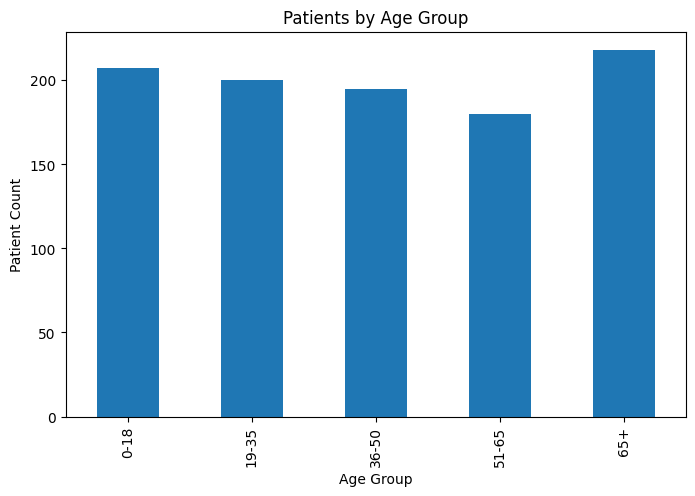

In [14]:


df = pd.read_csv("Hospital.csv")

bins = [0,18,35,50,65,100]
labels = ['0-18','19-35','36-50','51-65','65+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_count = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(8,5))
age_count.plot(kind='bar')
plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.show()

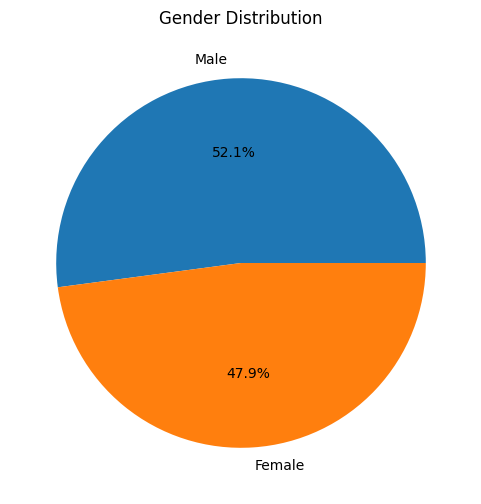

In [16]:


df = pd.read_csv("Hospital.csv")

gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()

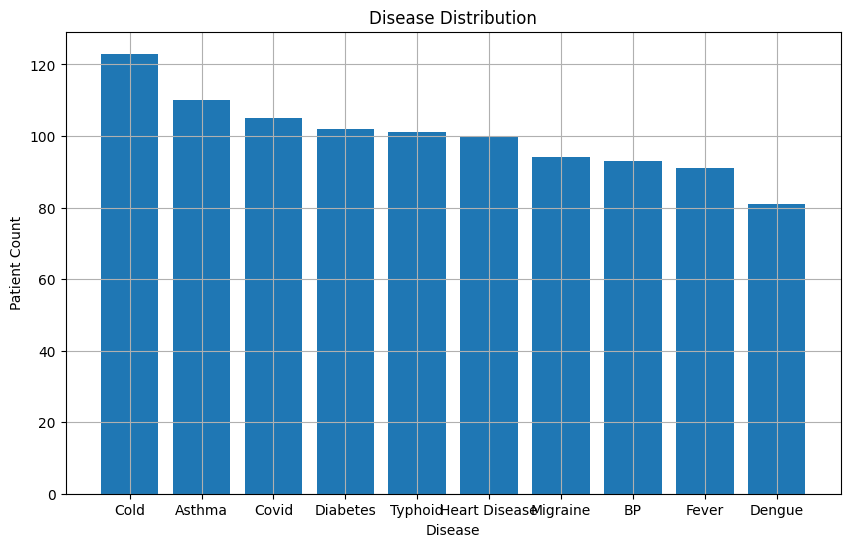

In [18]:
df = pd.read_csv("Hospital.csv")

disease_count = df['Disease'].value_counts()

plt.figure(figsize=(10,6))

plt.bar(
    disease_count.index,
    disease_count.values
)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Patient Count")

plt.grid(True)

plt.savefig("disease_chart.png")

plt.show()



In [19]:
top_disease = df['Disease'].value_counts().head(10)

print(top_disease)

Disease
Cold             123
Asthma           110
Covid            105
Diabetes         102
Typhoid          101
Heart Disease    100
Migraine          94
BP                93
Fever             91
Dengue            81
Name: count, dtype: int64


MALE VS FEMALE PATIENTS

In [20]:
print("Youngest:", df['Age'].min())

print("Oldest:", df['Age'].max())

Youngest: 1
Oldest: 85
